# 05 — H3: Cross-National Differences

**Hypothesis H3:** Country-level search activity for psychological help and evidence-based treatments is positively associated with mental health system development (WHO Mental Health Atlas 2020), GDP per capita, and scientific output in psychology; and negatively associated with religiosity (Pew Research).

**OSF pre-registration:** https://osf.io/7986u  
**OSF amendment (H3):** Kruskal-Wallis + Spearman as main analysis; simple linear regression as exploratory.

---

**Outcome variable (per OSF protocol — Indices section):**
```
mean_activity(country) = mean(RSV[country, all languages, all EBT keywords, 2018-2025])
```

**Analysis plan (per OSF amendment):**
1. **Kruskal-Wallis** — overall differences between country groups (main)
2. **Mann-Whitney** — pairwise group comparisons (main)
3. **Spearman** — correlations with each predictor + Bonferroni correction (main)
4. **Simple linear regression** — one predictor at a time, exploratory only

**Note:** N=21 countries limits statistical power. Results interpreted with caution.

**Predictors:** WHO Mental Health Atlas 2020, GDP per capita (log), SCImago psychology output (log), Pew Research religiosity.

## 0. Setup

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_DIR       = Path('../data')
PREDICTORS_CSV = DATA_DIR / 'predictors' / 'H3_predictors.csv'
OUTPUT_DIR     = Path('../results/H3')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CATEGORY   = 'evidence_based_treatments'
ALPHA      = 0.05
ALPHA_BONF = ALPHA / 4    # 4 predictors in Spearman → 0.0125
VIF_THRESH = 5.0

# Google Trends changed methodology effective Jan 1, 2022 (Myburgh, 2022).
# PRE_2022_END defines the cutoff for the sensitivity analysis
# using only unaffected (pre-change) data.
PRE_2022_END = pd.Timestamp('2021-12-31')

# Country groups (per config.py)
GROUPS = {
    'focal':   ['UA'],
    'group_a': ['DE','FR','PL','NL','LV','LT','EE','US','GB','AU','CA'],
    'group_b': ['GE','AM','AZ','KZ','UZ','MD','IL','JP','BR'],
}

print(f'Category:          {CATEGORY}')
print(f'Alpha Bonferroni:  {ALPHA_BONF:.4f}  (4 predictors)')
print(f'VIF threshold:     {VIF_THRESH}')
print(f'GT artifact cutoff: data before {PRE_2022_END.date()} = unaffected period')


Category:          evidence_based_treatments
Alpha Bonferroni:  0.0125  (4 predictors)
VIF threshold:     5.0
GT artifact cutoff: data before 2021-12-31 = unaffected period


## 1. Load outcome variable: mean RSV per country

In [2]:
def load_country_mean(country_dir: Path, category: str,
                      date_end: pd.Timestamp | None = None) -> float | None:
    """
    Per OSF protocol: mean RSV across all keywords, languages, and months.
    Returns a single float per country.

    date_end: if provided, only data up to this date is included.
              Used for Google Trends 2022 artifact sensitivity analysis.
    """
    csv_files = sorted(country_dir.glob(f'{category}__*__chunk*.csv'))
    if not csv_files:
        return None

    all_values = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, parse_dates=['date'], index_col='date')
            if 'isPartial' in df.columns:
                df = df[df['isPartial'] == False].drop(columns=['isPartial'])
            # Filter to pre-2022 period if requested
            if date_end is not None:
                df = df[df.index <= date_end]
            df = df.replace(0, np.nan)
            all_nan_cols = df.columns[df.isna().all()]
            df = df.drop(columns=all_nan_cols)
            if df.empty or df.shape[1] == 0:
                continue
            all_values.append(df.values.flatten())
        except Exception as e:
            print(f'  Warning: {f.name}: {e}')

    if not all_values:
        return None

    combined = np.concatenate(all_values)
    valid    = combined[~np.isnan(combined)]
    return float(np.mean(valid)) if len(valid) > 0 else None


raw_folders = sorted(DATA_DIR.glob('raw_*'))
if not raw_folders:
    raise FileNotFoundError(f'No raw_* folders found in {DATA_DIR}')
LATEST = raw_folders[-1]
print(f'Data folder: {LATEST.name}')

country_dirs = sorted([d for d in LATEST.iterdir() if d.is_dir()])

# ── Primary outcome: full period 2018–2025 ─────────────────────────────────────
country_means = {}
missing_countries = {}

for country_dir in country_dirs:
    code_ = country_dir.name
    mean_rsv = load_country_mean(country_dir, CATEGORY)
    if mean_rsv is None:
        missing_countries[code_] = 'No valid data'
    else:
        country_means[code_] = mean_rsv

print(f'\nPrimary outcome (2018–2025): {len(country_means)} countries')
if missing_countries:
    print(f'Missing: {list(missing_countries.keys())}')

# ── Sensitivity outcome: pre-2022 only (2018–2021) ────────────────────────────
country_means_pre2022 = {}

for country_dir in country_dirs:
    code_ = country_dir.name
    mean_rsv = load_country_mean(country_dir, CATEGORY, date_end=PRE_2022_END)
    if mean_rsv is not None:
        country_means_pre2022[code_] = mean_rsv

print(f'Sensitivity outcome (2018–2021): {len(country_means_pre2022)} countries')

df_outcome = pd.DataFrame.from_dict(country_means, orient='index', columns=['mean_rsv'])
df_outcome['mean_rsv_pre2022'] = pd.Series(country_means_pre2022)
df_outcome.index.name = 'country_code'
df_outcome = df_outcome.sort_values('mean_rsv', ascending=False)

print(f'\nMean RSV per country (full period | pre-2022):')
print(df_outcome.round(2).to_string())


Data folder: raw_20260417_211800

Primary outcome (2018–2025): 21 countries
Sensitivity outcome (2018–2021): 21 countries

Mean RSV per country (full period | pre-2022):
              mean_rsv  mean_rsv_pre2022
country_code                            
MD               38.09             40.67
AU               36.87             31.49
EE               35.58             31.35
GE               35.22             23.85
FR               34.64             31.90
DE               32.87             29.95
NL               32.63             28.58
LT               31.99             24.84
CA               30.90             28.24
BR               29.88             29.15
UA               29.81             21.91
LV               29.16             28.03
AM               29.10             27.36
GB               28.76             27.31
PL               27.36             19.03
IL               27.09             23.45
US               26.65             22.93
JP               25.00             22.21
KZ        

## 2. Load and merge predictors

In [3]:
df_pred = pd.read_csv(PREDICTORS_CSV, index_col='country_code')
print(f'Predictors loaded: {df_pred.shape[0]} countries, {df_pred.shape[1]} columns')
print(df_pred.columns.tolist())

df = df_outcome.join(df_pred, how='inner')
print(f'\nAfter merge: N = {len(df)} countries')

group_map  = {c: g for g, codes in GROUPS.items() for c in codes}
df['group'] = df.index.map(group_map).fillna('unknown')

print(f'\nGroup distribution:')
print(df['group'].value_counts().to_string())

N = len(df)
print(f'\nFinal N = {N} countries')


Predictors loaded: 21 countries, 5 columns
['country_name', 'who_atlas_score', 'gdp_per_capita', 'sci_output_psych', 'pew_religiosity']

After merge: N = 21 countries

Group distribution:
group
group_a    11
group_b     9
focal       1

Final N = 21 countries


## 3. Transformations and standardization

Per OSF protocol:
- GDP and SciOutput → log10 transformation
- All predictors → z-score standardization

In [4]:
# Log10 transformation for skewed predictors (GDP and scientific output)
df['gdp_log'] = np.log10(df['gdp_per_capita'])
df['sci_log'] = np.log10(df['sci_output_psych'])

for col, label in [('gdp_log', 'GDP log10'), ('sci_log', 'SciOutput log10')]:
    _, p = stats.shapiro(df[col])
    status = 'OK' if p >= ALPHA else 'still non-normal'
    print(f'{label}: Shapiro-Wilk p={p:.4f} → {status}')

# Standardize all predictors (z-scores) for comparability of regression coefficients
PREDICTORS = {
    'who_atlas_score': 'WHO Atlas',
    'gdp_log':         'GDP (log)',
    'sci_log':         'SciOutput (log)',
    'pew_religiosity': 'Religiosity',
}

for col in PREDICTORS:
    df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()

print(f'\nStandardized predictors created (z-scores).')
print(df[[f'{c}_z' for c in PREDICTORS]].describe().round(3).to_string())


GDP log10: Shapiro-Wilk p=0.0963 → OK
SciOutput log10: Shapiro-Wilk p=0.0902 → OK

Standardized predictors created (z-scores).
       who_atlas_score_z  gdp_log_z  sci_log_z  pew_religiosity_z
count              9.000     21.000     21.000             21.000
mean               0.000     -0.000      0.000              0.000
std                1.000      1.000      1.000              1.000
min               -0.826     -2.037     -1.899             -1.824
25%               -0.638     -0.969     -0.666             -0.942
50%               -0.429      0.254      0.186              0.333
75%               -0.158      0.887      0.780              0.889
max                1.868      1.335      1.223              1.093


## 4. Step 1 — Kruskal-Wallis: differences between country groups

In [5]:
groups_data = {
    g: df[df['group'] == g]['mean_rsv'].values
    for g in ['focal', 'group_a', 'group_b']
    if g in df['group'].values
}

# Kruskal-Wallis: tests whether at least one group has a different RSV distribution
kw_stat, kw_p = stats.kruskal(*groups_data.values())

print('Kruskal-Wallis Test')
print('─' * 40)
print(f'H = {kw_stat:.4f},  p = {kw_p:.4f}')
print(f'Groups: {list(groups_data.keys())}')
for g, vals in groups_data.items():
    print(f'  {g}: n={len(vals)}, median={np.median(vals):.2f}, mean={np.mean(vals):.2f}')
print()
print(f'Significant (p < {ALPHA}): {"YES" if kw_p < ALPHA else "NO"}')

# Mann-Whitney pairwise: non-parametric equivalent of t-test for two groups
# Bonferroni: 3 pairs → α = 0.05/3
alpha_mw = ALPHA / 3
print(f'\nMann-Whitney pairwise (Bonferroni α = {alpha_mw:.4f}):')
print('─' * 40)
mw_results = {}
group_list = list(groups_data.keys())
for i in range(len(group_list)):
    for j in range(i+1, len(group_list)):
        g1, g2 = group_list[i], group_list[j]
        u_stat, mw_p = stats.mannwhitneyu(
            groups_data[g1], groups_data[g2], alternative='two-sided')
        sig = 'SIG' if mw_p < alpha_mw else 'ns'
        print(f'  {g1} vs {g2}: U={u_stat:.1f}, p={mw_p:.4f} → {sig}')
        mw_results[f'{g1}_vs_{g2}'] = {
            'U': round(float(u_stat), 2),
            'p': round(float(mw_p), 4),
            'significant': bool(mw_p < alpha_mw)
        }


Kruskal-Wallis Test
────────────────────────────────────────
H = 2.7758,  p = 0.2496
Groups: ['focal', 'group_a', 'group_b']
  focal: n=1, median=29.81, mean=29.81
  group_a: n=11, median=31.99, mean=31.58
  group_b: n=9, median=27.09, mean=27.13

Significant (p < 0.05): NO

Mann-Whitney pairwise (Bonferroni α = 0.0167):
────────────────────────────────────────
  focal vs group_a: U=4.0, p=0.8333 → ns
  focal vs group_b: U=6.0, p=0.8000 → ns
  group_a vs group_b: U=71.0, p=0.1106 → ns


## 5. Step 2 — Spearman correlations with predictors

In [6]:
print('Spearman Rank Correlations')
print(f'Bonferroni α = {ALPHA_BONF:.4f}  (4 predictors)')
print('─' * 55)

spearman_results = {}
for col, label in PREDICTORS.items():
    rho, p = stats.spearmanr(df['mean_rsv'], df[col])
    sig = 'SIG' if p < ALPHA_BONF else 'ns'
    direction = '+' if rho > 0 else '-'
    print(f'  {label:20s}  ρ={rho:+.4f}  p={p:.4f}  → {sig}')
    spearman_results[col] = {
        'label': label,
        'rho': round(float(rho), 4),
        'p': round(float(p), 4),
        'significant': bool(p < ALPHA_BONF),
        'direction': direction
    }


Spearman Rank Correlations
Bonferroni α = 0.0125  (4 predictors)
───────────────────────────────────────────────────────
  WHO Atlas             ρ=+nan  p=nan  → ns
  GDP (log)             ρ=+0.2091  p=0.3630  → ns
  SciOutput (log)       ρ=+0.3610  p=0.1078  → ns
  Religiosity           ρ=-0.2377  p=0.2996  → ns


## 6. Step 3 — Simple linear regression (exploratory)

Per OSF amendment: simple linear regression run separately for each predictor.  
This is **exploratory only** — not a primary analysis.  
Results interpreted with caution given N=21.

In [7]:
def run_simple_ols(y, x_series, label, alpha_thresh):
    """
    Fit simple OLS: Y ~ predictor.
    Includes Cook's distance outlier detection and Shapiro-Wilk on residuals.
    """
    mask   = ~np.isnan(x_series) & ~np.isnan(y)
    y_fit  = y[mask]
    x_fit  = x_series[mask]
    idx_fit = np.where(mask)[0]

    X     = sm.add_constant(x_fit)
    model = sm.OLS(y_fit, X).fit()

    # Cook's distance: threshold = 4/n (standard rule of thumb)
    influence    = model.get_influence()
    cooks_d      = influence.cooks_distance[0]
    cooks_thresh = 4 / len(y_fit)
    influential  = idx_fit[cooks_d > cooks_thresh].tolist()

    sw_stat, sw_p = stats.shapiro(model.resid)
    ci    = model.conf_int()
    b1    = model.params[1]
    p_b1  = model.pvalues[1]
    r2    = model.rsquared

    print(f'  {label:22s}  β={b1:+.4f}  '
          f'[{ci[1][0]:+.4f}, {ci[1][1]:+.4f}]  '
          f'p={p_b1:.4f}  R²={r2:.4f}  '
          f'→ {"SIG" if p_b1 < alpha_thresh else "ns"}'
          f'  Cook\'s outliers: {[df.index[i] for i in influential]}')

    return {
        'label': label,
        'n': int(len(y_fit)),
        'beta1': round(float(b1), 4),
        'beta1_ci': [round(float(ci[1][0]), 4), round(float(ci[1][1]), 4)],
        'p_value': round(float(p_b1), 4),
        'r_squared': round(float(r2), 4),
        'shapiro_wilk_p': round(float(sw_p), 4),
        'significant': bool(p_b1 < alpha_thresh),
        'influential_countries': [df.index[i] for i in influential],
        '_model': model,
        '_mask': mask,
    }


print('Simple Linear Regression — Exploratory (one predictor at a time)')
print(f'Significance threshold: α = {ALPHA}  (exploratory, no Bonferroni)')
print('─' * 80)

simple_ols_results = {}
for col, label in PREDICTORS.items():
    x_vals = df[col].values.astype(float)
    simple_ols_results[col] = run_simple_ols(df['mean_rsv'].values, x_vals, label, ALPHA)

# Sensitivity: outliers excluded
print()
print('Sensitivity — outliers excluded:')
print('─' * 80)
simple_ols_sensitivity = {}
for col, label in PREDICTORS.items():
    res = simple_ols_results[col]
    if not res['influential_countries']:
        print(f'  {label:22s}  No influential outliers — sensitivity not needed.')
        continue
    excl    = res['influential_countries']
    df_excl = df[~df.index.isin(excl)]

    # BUG (original): both arguments passed df_excl[col] — predictor regressed on itself
    # producing degenerate results (R²=1.0, p=0.0, beta1=1.0).
    # Preserved below for reproducibility; corrected version follows.
    #
    # res_excl = run_simple_ols(df_excl[col].values.astype(float),
    #                            df_excl[col].values.astype(float),
    #                            f'{label} (excl. {excl})', ALPHA)

    # FIXED: correct Y = mean_rsv, X = predictor
    res_excl = run_simple_ols(df_excl['mean_rsv'].values.astype(float),
                               df_excl[col].values.astype(float),
                               f'{label} (excl. {excl})', ALPHA)
    simple_ols_sensitivity[col] = res_excl

Simple Linear Regression — Exploratory (one predictor at a time)
Significance threshold: α = 0.05  (exploratory, no Bonferroni)
────────────────────────────────────────────────────────────────────────────────
  WHO Atlas               β=+0.4160  [-0.7349, +1.5669]  p=0.4210  R²=0.0945  → ns  Cook's outliers: []
  GDP (log)               β=+4.1224  [-1.7451, +9.9899]  p=0.1578  R²=0.1022  → ns  Cook's outliers: ['MD', 'UZ', 'AZ']
  SciOutput (log)         β=+3.4791  [+0.2132, +6.7449]  p=0.0380  R²=0.2074  → SIG  Cook's outliers: ['MD', 'AZ']
  Religiosity             β=-0.0827  [-0.2125, +0.0471]  p=0.1983  R²=0.0855  → ns  Cook's outliers: ['MD', 'JP', 'AZ']

Sensitivity — outliers excluded:
────────────────────────────────────────────────────────────────────────────────
  WHO Atlas               No influential outliers — sensitivity not needed.
  GDP (log) (excl. ['MD', 'UZ', 'AZ'])  β=+1.2441  [-4.0555, +6.5437]  p=0.6255  R²=0.0152  → ns  Cook's outliers: ['EE']
  SciOutput (log) (

## 5b. Sensitivity — Google Trends 2022 artifact check

Per Myburgh (2022), Google Trends updated its sampling methodology effective **1 January 2022**,
resulting in systematically higher RSV values from that date onwards.

**Approach:** re-run Spearman and Kruskal-Wallis using `mean_rsv_pre2022`
(computed from 2018–2021 data only). Consistent direction and significance
between full-period and pre-2022 analyses supports robustness of findings.


In [8]:
# ── Google Trends 2022 artifact sensitivity analysis ──────────────────────────
# Re-run Spearman and Kruskal-Wallis using mean_rsv computed from
# pre-2022 data only (2018–2021), which is unaffected by Google's
# January 2022 methodology change (Myburgh, 2022, IJERPH 19(22):15396).
#
# Rationale: if rank-based results (Spearman ρ, KW) are consistent
# between full-period and pre-2022-only analyses, findings are robust
# to the GT artifact.

print('Google Trends 2022 Artifact — Sensitivity Analysis')
print('Outcome: mean_rsv computed from 2018–2021 data only')
print('=' * 60)
print()

# Spearman with pre-2022 outcome
print('Spearman Rank Correlations (pre-2022 outcome):')
print('─' * 55)
spearman_pre2022 = {}
for col, label in PREDICTORS.items():
    mask = df['mean_rsv_pre2022'].notna() & df[col].notna()
    rho, p = stats.spearmanr(df.loc[mask, 'mean_rsv_pre2022'], df.loc[mask, col])
    sig = 'SIG' if p < ALPHA_BONF else 'ns'
    rho_full = spearman_results[col]['rho']
    consistent = '✓ consistent' if (rho * rho_full > 0) else '✗ direction differs'
    print(f'  {label:20s}  ρ={rho:+.4f}  p={p:.4f}  → {sig}  [{consistent}]')
    spearman_pre2022[col] = {
        'rho': round(float(rho), 4),
        'p': round(float(p), 4),
        'significant': bool(p < ALPHA_BONF),
    }

# Kruskal-Wallis with pre-2022 outcome
print()
print('Kruskal-Wallis (pre-2022 outcome):')
print('─' * 40)
groups_pre2022 = {
    g: df[df['group'] == g]['mean_rsv_pre2022'].dropna().values
    for g in ['focal', 'group_a', 'group_b']
    if g in df['group'].values
}
kw_stat_pre, kw_p_pre = stats.kruskal(*groups_pre2022.values())
consistent_kw = '✓ consistent' if (kw_p < ALPHA) == (kw_p_pre < ALPHA) else '✗ differs'
print(f'H = {kw_stat_pre:.4f},  p = {kw_p_pre:.4f}  → {consistent_kw}')
print()
print('Interpretation:')
print('  If Spearman directions and KW significance are consistent between')
print('  full-period and pre-2022 analyses → findings are robust to the')
print('  Google Trends January 2022 methodology change.')


Google Trends 2022 Artifact — Sensitivity Analysis
Outcome: mean_rsv computed from 2018–2021 data only

Spearman Rank Correlations (pre-2022 outcome):
───────────────────────────────────────────────────────
  WHO Atlas             ρ=+0.1757  p=0.6511  → ns  [✗ direction differs]
  GDP (log)             ρ=+0.3532  p=0.1162  → ns  [✓ consistent]
  SciOutput (log)       ρ=+0.3974  p=0.0744  → ns  [✓ consistent]
  Religiosity           ρ=-0.3532  p=0.1162  → ns  [✓ consistent]

Kruskal-Wallis (pre-2022 outcome):
────────────────────────────────────────
H = 3.6857,  p = 0.1584  → ✓ consistent

Interpretation:
  If Spearman directions and KW significance are consistent between
  full-period and pre-2022 analyses → findings are robust to the
  Google Trends January 2022 methodology change.


In [9]:
# (Multiple OLS regression removed per OSF amendment — see simple regression above)

## 7. Visualization

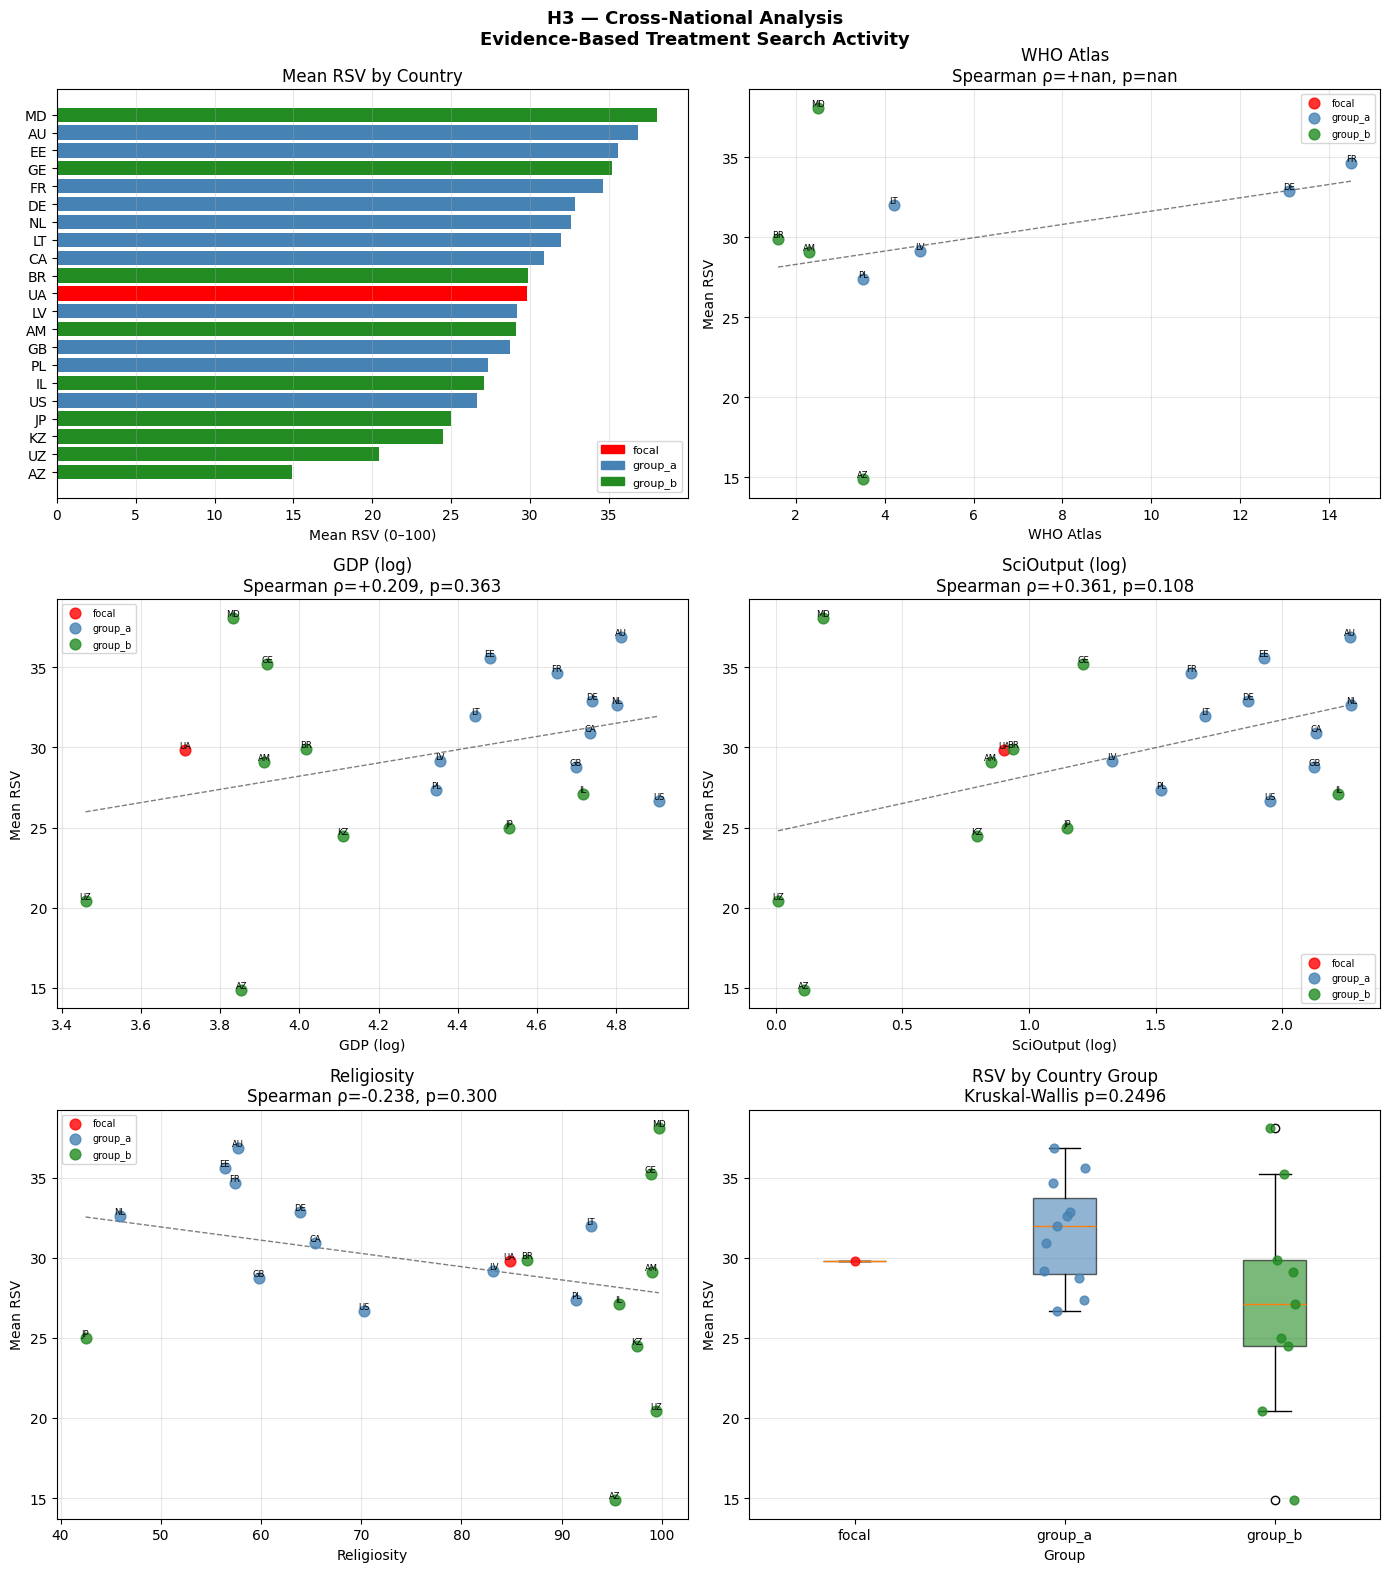

Figure saved to ..\results\H3\H3_cross_national.png


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('H3 — Cross-National Analysis\nEvidence-Based Treatment Search Activity',
             fontsize=13, fontweight='bold')

group_colors = {'focal': 'red', 'group_a': 'steelblue', 'group_b': 'forestgreen', 'unknown': 'grey'}

# ── Plot 1: Mean RSV by country (bar chart) ─────────────────────────────────────
ax1 = axes[0, 0]
colors = [group_colors.get(df.loc[c, 'group'], 'grey') for c in df_outcome.index
          if c in df.index]
df_plot = df.sort_values('mean_rsv', ascending=True)
bars = ax1.barh(df_plot.index,
                df_plot['mean_rsv'],
                color=[group_colors.get(df_plot.loc[c, 'group'], 'grey')
                       for c in df_plot.index])
ax1.set_title('Mean RSV by Country')
ax1.set_xlabel('Mean RSV (0–100)')
patches = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()
           if k != 'unknown']
ax1.legend(handles=patches, fontsize=8)
ax1.grid(alpha=0.3, axis='x')

# ── Plots 2-5: Scatter plots for each predictor ─────────────────────────────────
plot_positions = [(0,1), (1,0), (1,1), (2,0)]
for (row, col), (pred_col, label) in zip(plot_positions, PREDICTORS.items()):
    ax = axes[row, col]
    for group, color in group_colors.items():
        if group == 'unknown':
            continue
        mask = df['group'] == group
        ax.scatter(df[mask][pred_col], df[mask]['mean_rsv'],
                   c=color, label=group, s=60, alpha=0.8, zorder=3)
        # Country labels
        for idx in df[mask].index:
            ax.annotate(idx,
                        (df.loc[idx, pred_col], df.loc[idx, 'mean_rsv']),
                        fontsize=6, ha='center', va='bottom')

    # Regression line (only for non-missing values)
    mask_valid = df[pred_col].notna() & df['mean_rsv'].notna()
    if mask_valid.sum() >= 3:
        x_vals = df.loc[mask_valid, pred_col].values
        y_vals = df.loc[mask_valid, 'mean_rsv'].values
        z = np.polyfit(x_vals, y_vals, 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, p_line(x_line), 'k--', linewidth=1, alpha=0.5)

    rho = spearman_results[pred_col]['rho']
    p_sp = spearman_results[pred_col]['p']
    ax.set_title(f'{label}\nSpearman ρ={rho:+.3f}, p={p_sp:.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Mean RSV')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# ── Plot 6: Boxplot — RSV by country group ─────────────────────────────────────
ax6 = axes[2, 1]
group_order = [g for g in ['focal', 'group_a', 'group_b'] if g in df['group'].values]
box_data    = [df[df['group'] == g]['mean_rsv'].values for g in group_order]
bp = ax6.boxplot(box_data, labels=group_order, patch_artist=True)
group_color_list = [group_colors[g] for g in group_order]
for patch, color in zip(bp['boxes'], group_color_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
# Overlay individual points
for j, (g, vals) in enumerate(zip(group_order, box_data)):
    ax6.scatter(np.full(len(vals), j+1) + np.random.uniform(-0.1, 0.1, len(vals)),
                vals, color=group_colors[g], s=40, zorder=3, alpha=0.8)
ax6.set_title(f'RSV by Country Group\nKruskal-Wallis p={kw_p:.4f}')
ax6.set_xlabel('Group')
ax6.set_ylabel('Mean RSV')
ax6.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'H3_cross_national.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {OUTPUT_DIR / "H3_cross_national.png"}')

## 8. Export results

In [11]:
# Remove non-serializable keys
simple_export = {}
for col, res in simple_ols_results.items():
    simple_export[col] = {k: v for k, v in res.items() if not k.startswith('_')}

simple_sens_export = {}
for col, res in simple_ols_sensitivity.items():
    simple_sens_export[col] = {k: v for k, v in res.items() if not k.startswith('_')}

full_results = {
    'hypothesis':                    'H3',
    'category':                      CATEGORY,
    'n_countries':                   N,
    'alpha':                         ALPHA,
    'alpha_bonferroni_spearman':     ALPHA_BONF,
    'analysis_note':                 'Kruskal-Wallis + Spearman = main; simple linear regression = exploratory',
    'gt_artifact_note':              'Sensitivity with pre-2022 data included (Myburgh 2022)',

    'kruskal_wallis': {
        'H': round(float(kw_stat), 4),
        'p': round(float(kw_p), 4),
        'significant': bool(kw_p < ALPHA),
        'groups_n':      {g: len(v) for g, v in groups_data.items()},
        'groups_median': {g: round(float(np.median(v)), 3) for g, v in groups_data.items()},
    },
    'mann_whitney':                           mw_results,
    'spearman':                               spearman_results,
    'spearman_pre2022_sensitivity':           spearman_pre2022,
    'kw_pre2022_sensitivity': {
        'H': round(float(kw_stat_pre), 4),
        'p': round(float(kw_p_pre), 4),
        'significant': bool(kw_p_pre < ALPHA),
    },
    'simple_linear_regression_exploratory':  simple_export,
    'sensitivity_outliers_excluded':         simple_sens_export,
}

results_path = OUTPUT_DIR / 'H3_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(full_results, f, indent=2, ensure_ascii=False)

df_export = df[['country_name', 'group', 'mean_rsv', 'mean_rsv_pre2022'] +
               list(PREDICTORS.keys())].copy()
df_export.to_csv(OUTPUT_DIR / 'H3_country_data.csv')

print('Results saved:')
print(f'  {results_path}')
print(f'  {OUTPUT_DIR / "H3_country_data.csv"}')
print()
print('═' * 55)
print('SUMMARY — H3')
print('═' * 55)
kw = full_results['kruskal_wallis']
print(f'Kruskal-Wallis: H={kw["H"]}, p={kw["p"]} → {"SIGNIFICANT" if kw["significant"] else "ns"}')
print()
print('Spearman correlations (main):')
for col, res in spearman_results.items():
    print(f'  {res["label"]:20s}  ρ={res["rho"]:+.4f}  p={res["p"]:.4f}  '
          f'{"SIG" if res["significant"] else "ns"}')
print()
print('Simple regression (exploratory):')
for col, res in simple_export.items():
    print(f'  {res["label"]:20s}  β={res["beta1"]:+.4f}  '
          f'p={res["p_value"]:.4f}  R²={res["r_squared"]:.4f}  '
          f'{"SIG" if res["significant"] else "ns"}')


Results saved:
  ..\results\H3\H3_results.json
  ..\results\H3\H3_country_data.csv

═══════════════════════════════════════════════════════
SUMMARY — H3
═══════════════════════════════════════════════════════
Kruskal-Wallis: H=2.7758, p=0.2496 → ns

Spearman correlations (main):
  WHO Atlas             ρ=+nan  p=nan  ns
  GDP (log)             ρ=+0.2091  p=0.3630  ns
  SciOutput (log)       ρ=+0.3610  p=0.1078  ns
  Religiosity           ρ=-0.2377  p=0.2996  ns

Simple regression (exploratory):
  WHO Atlas             β=+0.4160  p=0.4210  R²=0.0945  ns
  GDP (log)             β=+4.1224  p=0.1578  R²=0.1022  ns
  SciOutput (log)       β=+3.4791  p=0.0380  R²=0.2074  SIG
  Religiosity           β=-0.0827  p=0.1983  R²=0.0855  ns
